# 2 · What changes when we change hyperparameters?

The baseline deserves a real tuning pass. These experiments change **one variable at a time** around a common MLP configuration while holding the bounded TinyStories data, tokenizer, train-only vocabulary, seed, batch size, and target-token budget fixed.

```text
context w ─┐
embedding d ├─→ first-layer input width w·d ─→ parameters / compute
hidden h ───┘
learning rate + weight decay ─→ optimization / generalization
```

The included artifact is a measured sweep, not illustrative numbers. Test data was not used for selection.


In [1]:
from pathlib import Path
import json, math, os, sys, time

HERE = Path.cwd()
if not (HERE / "wordlm.py").exists():
    matches = list(Path.cwd().rglob("word-level-next-token/wordlm.py"))
    if not matches:
        raise FileNotFoundError("Run this notebook from its word-level-next-token directory.")
    HERE = matches[0].parent
sys.path.insert(0, str(HERE))

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from wordlm import *

SEED = 11
seed_everything(SEED)
DEVICE = resolve_device(os.getenv("WORDLM_DEVICE", "auto"))
plt.style.use("seaborn-v0_8-whitegrid")
print(f"torch={torch.__version__}  device={DEVICE}")


torch=2.14.0  device=mps


In [2]:
sweep_path = HERE / "artifacts" / "mlp_sweep.json"
comparison_path = HERE / "artifacts" / "comparison_tuning.json"
if not sweep_path.exists() or not comparison_path.exists():
    raise FileNotFoundError("Run run_experiments.py --mode sweep or use the included artifacts.")
sweep = read_json(sweep_path)
comparison_tuning = read_json(comparison_path)
records = sweep["records"]
print("test set used during sweep:", sweep["protocol"]["test_set_used"])
print("runs:", len(records), "selection seed:", sweep["protocol"]["selection_seed"])
print("selected primary config:", sweep["selected_primary_mlp_config"])
assert sweep["protocol"]["test_set_used"] is False


test set used during sweep: False
runs: 12 selection seed: 7
selected primary config: {'context_len': 16, 'd_embed': 64, 'hidden': 256, 'learning_rate': 0.003, 'sweep_axis': 'weight_decay', 'sweep_value': 0.001, 'weight_decay': 0.001}


## 1. Make the growing input visible

For vocabulary size $|\mathcal V|$, context $w$, embedding width $d$, and hidden width $h$:

$$\text{MLP parameters}=|\mathcal V|d+(wd)h+h+h|\mathcal V|+|\mathcal V|.$$

The context length affects the $wd\times h$ matrix directly. It does not change the embedding lookup width or vocabulary output width.


In [3]:
baseline = sweep["protocol"]["baseline"]
vocab_size = sweep["records"][0]["model_config"].get("vocab_size", 4000)
print(f"{'w':>4} {'d':>4} {'w·d input':>10} {'W1 weights':>12}")
for w in [8, 16, 32, 64]:
    d, h = baseline["d_embed"], baseline["hidden"]
    print(f"{w:4d} {d:4d} {w*d:10d} {w*d*h:12,d}")


   w    d  w·d input   W1 weights
   8   64        512      131,072
  16   64       1024      262,144
  32   64       2048      524,288
  64   64       4096    1,048,576


## 2. Final validation loss, parameter count, and runtime

Lower validation cross-entropy is better. Parameter count is an architectural cost; runtime is a measurement from this run and environment, not a hardware-independent law.


In [4]:
ordered = sorted(records, key=lambda r: r["validation_loss"])
print(f"{'axis':>14} {'value':>10} {'val CE':>8} {'gap':>8} {'params':>11} {'multiplies':>12} {'seconds':>8}")
for r in ordered:
    cfg = r["model_config"]
    gap = r["validation_loss"] - r["final_train_batch_loss"]
    print(f"{cfg['sweep_axis']:>14} {str(cfg['sweep_value']):>10} {r['validation_loss']:8.3f} "
          f"{gap:8.3f} {r['parameter_count']:11,d} {r['approximate_forward_multiplies']:12,d} {r['runtime_seconds']:8.1f}")


          axis      value   val CE      gap      params   multiplies  seconds
   context_len          8    3.877    0.273   1,415,328    1,155,072      4.8
  weight_decay      0.001    3.991    0.328   1,546,400    1,286,144      4.5
      baseline         16    3.994    0.300   1,546,400    1,286,144      4.9
  weight_decay        0.0    3.994    0.277   1,546,400    1,286,144      4.5
        hidden        128    4.002    0.359     903,200      643,072      3.5
        hidden        384    4.005    0.360   2,189,600    1,929,216      5.6
       d_embed         96    4.017    0.347   1,805,472    1,417,216      5.0
       d_embed         32    4.023    0.253   1,287,328    1,155,072      4.1
 learning_rate      0.001    4.055    0.260   1,546,400    1,286,144      4.6
 learning_rate      0.006    4.156    0.287   1,546,400    1,286,144      4.5
   context_len         32    4.180    0.308   1,808,544    1,548,288      5.3
   context_len         64    4.337    0.306   2,332,832    2,072

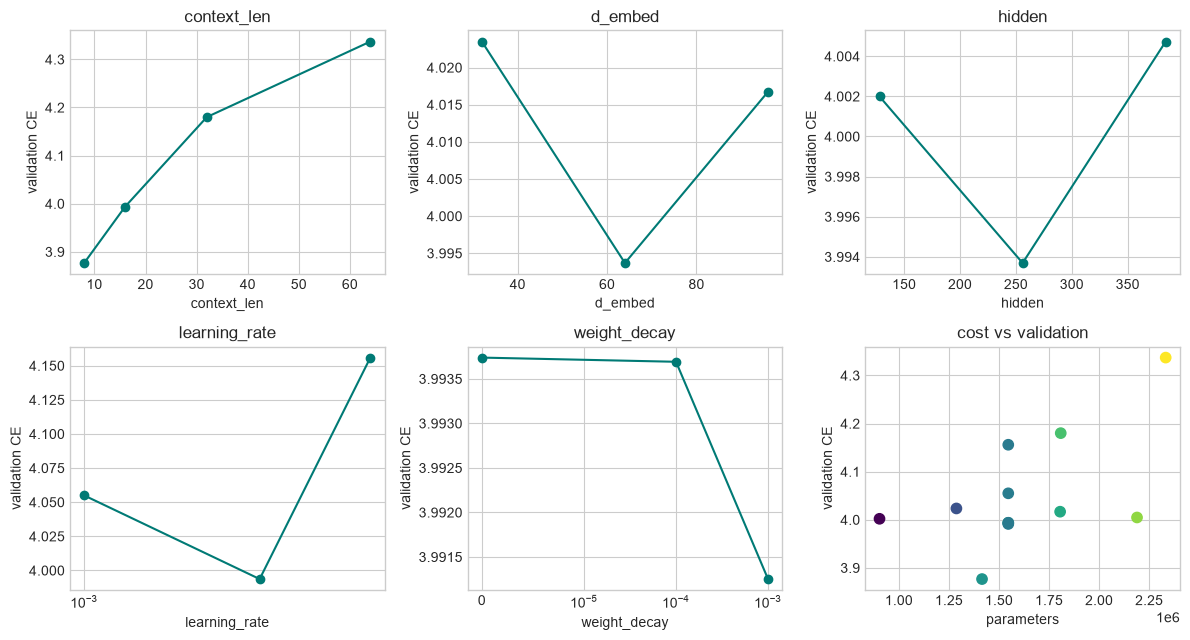

In [5]:
axes = ["context_len", "d_embed", "hidden", "learning_rate", "weight_decay"]
fig, panels = plt.subplots(2, 3, figsize=(12, 6.5))
panels = panels.ravel()
for ax, axis in zip(panels, axes):
    relevant = [r for r in records if r["model_config"]["sweep_axis"] in (axis, "baseline")]
    relevant = sorted(relevant, key=lambda r: float(r["model_config"][axis]))
    x = [float(r["model_config"][axis]) for r in relevant]
    y = [r["validation_loss"] for r in relevant]
    ax.plot(x, y, "o-", color="#007a75")
    ax.set(title=axis, xlabel=axis, ylabel="validation CE")
    if axis in ("learning_rate", "weight_decay"):
        ax.set_xscale("symlog", linthresh=1e-5)
panels[-1].scatter(
    [r["parameter_count"] for r in records], [r["validation_loss"] for r in records],
    c=[r["runtime_seconds"] for r in records], cmap="viridis", s=55,
)
panels[-1].set(title="cost vs validation", xlabel="parameters", ylabel="validation CE")
fig.tight_layout(); plt.show()


**Interpretation.** Wider or longer is not automatically better under a fixed token budget. Extra capacity changes both optimization and overfitting pressure. Learning rate often moves the result more than a modest width change, which is why an intentionally weak baseline would make an architecture comparison meaningless.

## 3. Learning curves, not only final dots


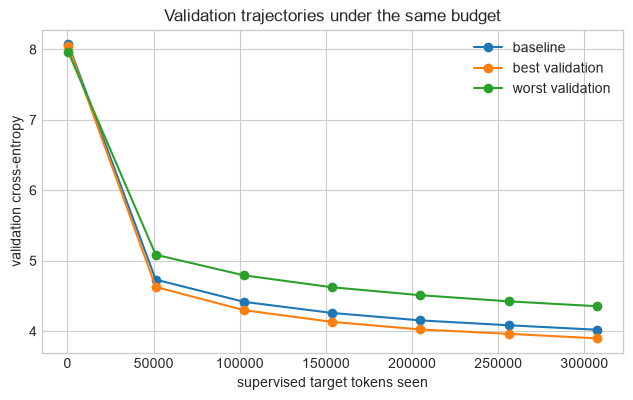

In [6]:
# Show the baseline plus the best and worst validation runs.
baseline_run = next(r for r in records if r["model_config"]["sweep_axis"] == "baseline")
chosen = [baseline_run, ordered[0], ordered[-1]]
labels = ["baseline", "best validation", "worst validation"]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for r, label in zip(chosen, labels):
    trace = r["trace"]
    ax.plot([p["tokens_seen"] for p in trace], [p["validation_loss"] for p in trace], "o-", label=label)
ax.set(xlabel="supervised target tokens seen", ylabel="validation cross-entropy", title="Validation trajectories under the same budget")
ax.legend(); plt.show()


## 4. The selection rule

The primary comparison in Notebook 4 fixes a **shared 64-word context** for both architectures. This is a deliberate long-context stress test: the MLP must concatenate all 64 embedding rows, while attention can learn a content-weighted summary. Learning rate and weight decay are tuned separately for each model on validation, with identical selection seeds, widths, batch size, and target-token budget. The test split remains sealed.


In [7]:
print("comparison selection protocol:", comparison_tuning["protocol"])
print("selected without test data:")
for kind, config in comparison_tuning["selected_configs"].items():
    print(f"  {kind:>9s}: {config}")
assert comparison_tuning["protocol"]["test_set_used"] is False
assert comparison_tuning["protocol"]["same_context_length"] == 64


comparison selection protocol: {'batch_size': 512, 'same_context_length': 64, 'same_embedding_and_hidden_widths': True, 'same_steps_batch_size_and_seed': True, 'selection_metric': 'token-weighted validation cross-entropy', 'selection_seed': 7, 'steps_per_run': 3000, 'test_set_used': False}
selected without test data:
  attention: {'context_len': 64, 'd_embed': 64, 'hidden': 256, 'learning_rate': 0.003, 'sweep_axis': 'comparison_tune', 'sweep_value': 'lr=0.003,wd=0.001', 'weight_decay': 0.001}
        mlp: {'context_len': 64, 'd_embed': 64, 'hidden': 256, 'learning_rate': 0.001, 'sweep_axis': 'comparison_tune', 'sweep_value': 'lr=0.001,wd=0.0001', 'weight_decay': 0.0001}


**Limit.** This is a modest, controlled sweep—not exhaustive hyperparameter optimization. It establishes a credible baseline at a stated budget. The untouched test split is evaluated only after both MLP and attention configurations are frozen.
